In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import pickle

df=pd.read_csv('labeled_selected_routes_group_1.csv')

# przykładowo 6 równych kwantyli (możesz zmienić na 5,7)
df['delay_bin_q'] = pd.qcut(df['delay_min'].clip(lower=0), q=6, labels=False, duplicates='drop')

# df[df['delay_min']<-200]
df

,Unnamed: 0.1,Unnamed: 0,vehicle_id,trip_id,stop_sequence,day,planned_departure,timestamp,delay_sec,delay_min,route_name,time_label,delay_label,sin_time,cos_time,delay_bin_q
0,0,2,53,block_487_trip_6_service_1,14,2,2025-06-03 10:22:00,2025-06-03 10:25:59,239.0,3.983333,503,1020,3,0.422618,-0.906308,3
1,1,5,61,block_147_trip_7_service_1,3,2,2025-06-03 10:24:00,2025-06-03 10:25:59,119.0,1.983333,469,1020,2,0.422618,-0.906308,2
2,2,14,283,block_220_trip_8_service_1,15,2,2025-06-03 10:25:00,2025-06-03 10:25:57,57.0,0.950000,192,1025,1,0.402747,-0.915311,1
3,3,30,2,block_199_trip_8_service_1,3,2,2025-06-03 10:26:00,2025-06-03 10:26:29,29.0,0.483333,179,1025,1,0.402747,-0.915311,1
4,4,32,27,block_196_trip_7_service_1,16,2,2025-06-03 10:25:00,2025-06-03 10:26:29,89.0,1.483333,179,1025,2,0.402747,-0.915311,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140812,142204,1349865,573,block_964_trip_13_service_3,23,7,2025-06-29 23:34:00,2025-06-29 23:35:28,88.0,1.466667,469,2330,2,-0.130526,0.991445,2
140813,142205,1349869,573,block_964_trip_13_service_3,25,7,2025-06-29 23:40:00,2025-06-29 23:42:03,123.0,2.050000,469,2340,2,-0.087156,0.996195,2
140814,142206,1349870,573,block_964_trip_13_service_3,26,7,2025-06-29 23:43:00,2025-06-29 23:45:05,125.0,2.083333,469,2340,2,-0.087156,0.996195,2
140815,142207,1349873,573,block_964_trip_13_service_3,27,7,2025-06-29 23:45:00,2025-06-29 23:46:33,93.0,1.550000,469,2345,2,-0.065403,0.997859,2


In [2]:

file=open('../data/wyniki_predykcji/grupa_1_klasyfikacja_bez_cv_20_epoch','rb')
wyniki_zapis=pickle.load(file)
file.close()


<Figure size 1200x500 with 0 Axes>

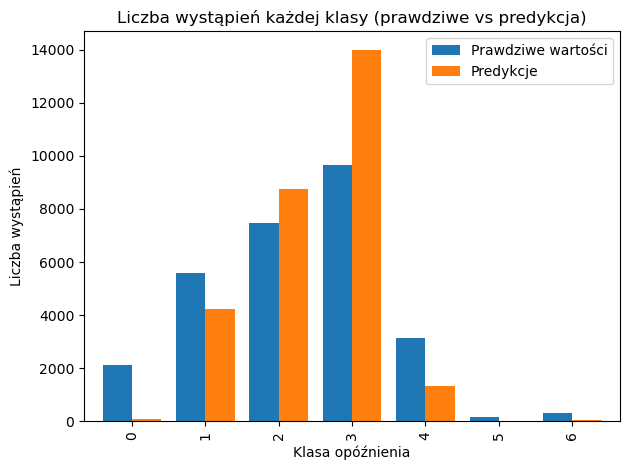

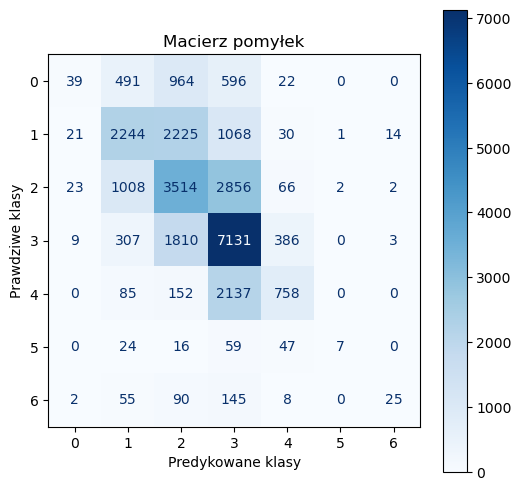

In [3]:
df_results=wyniki_zapis[2]

plt.figure(figsize=(12,5))
y_true_counts = df_results['y_true'].value_counts().sort_index()
y_pred_counts = df_results['y_pred'].value_counts().sort_index()

df_counts = pd.DataFrame({
    "Prawdziwe wartości": y_true_counts,
    "Predykcje": y_pred_counts
}).fillna(0).astype(int)

df_counts.plot(kind="bar", width=0.8)
plt.xlabel("Klasa opóźnienia")
plt.ylabel("Liczba wystąpień")
plt.title("Liczba wystąpień każdej klasy (prawdziwe vs predykcja)")
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(df_results['y_true'], df_results['y_pred'])
classes = sorted(df_results['y_true'].unique())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title(f"Macierz pomyłek")
plt.xlabel("Predykowane klasy")
plt.ylabel("Prawdziwe klasy")
plt.show()

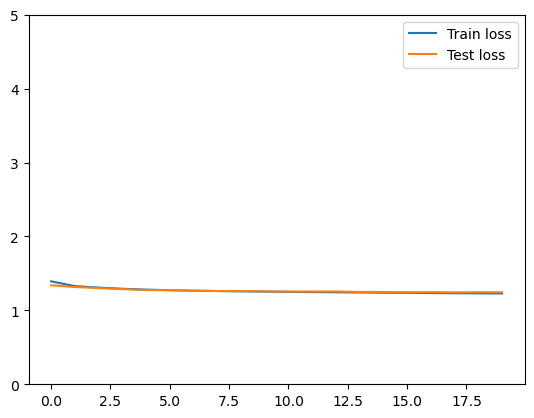

In [4]:
plt.figure
plt.plot(wyniki_zapis[0],label='Train loss')
plt.plot(wyniki_zapis[1],label='Test loss')
plt.ylim([0,5])
plt.legend()
plt.show()

In [7]:


plik=open('../data/wyniki_predykcji/grupa_2_klasyfikacja_5cv_20_epoch','rb')
wyniki=pickle.load(plik)
plik.close()

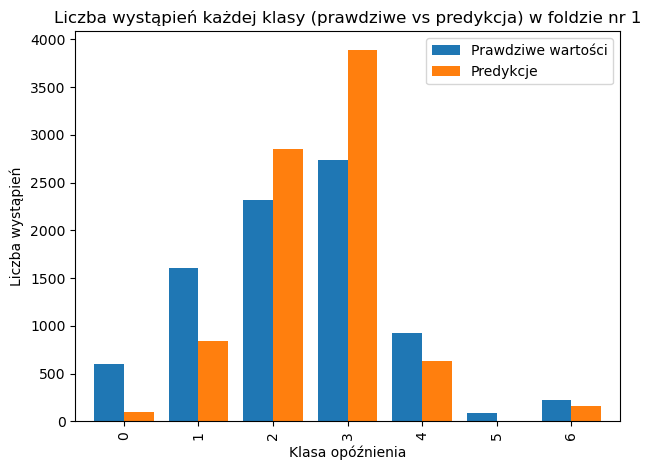

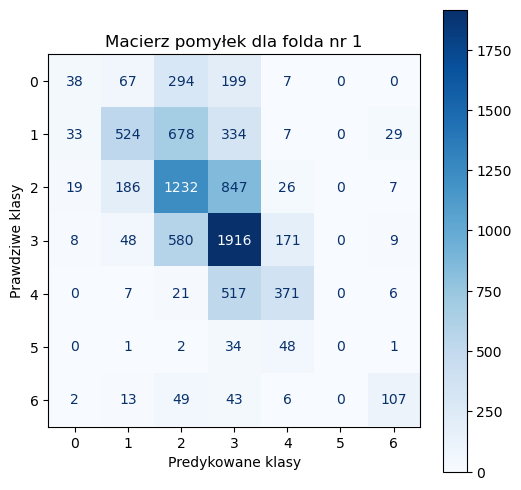

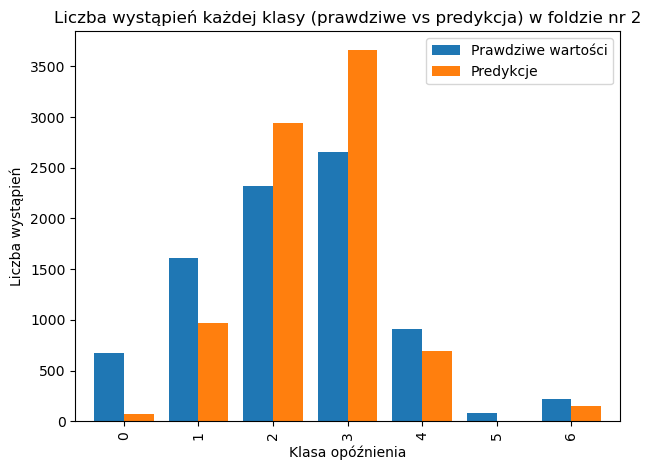

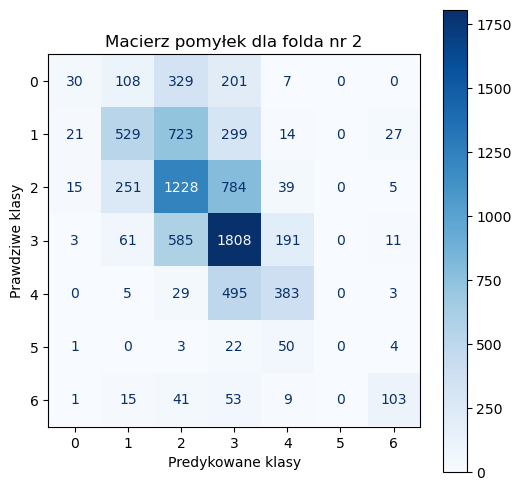

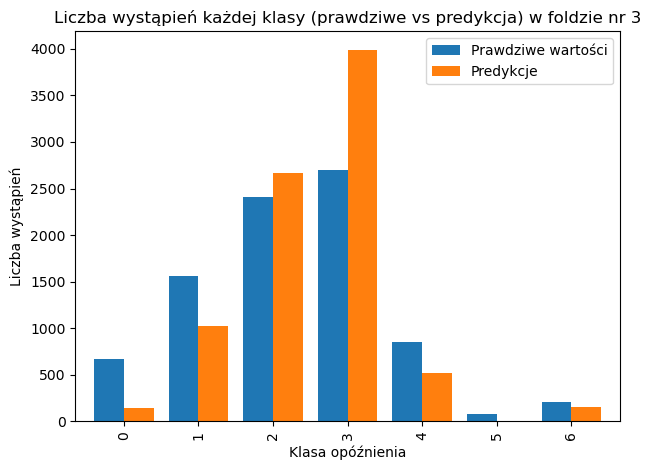

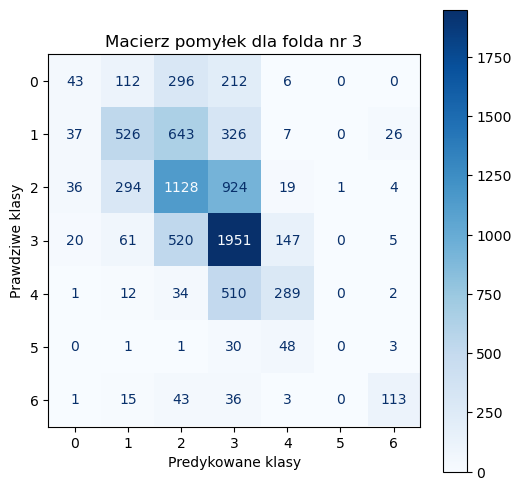

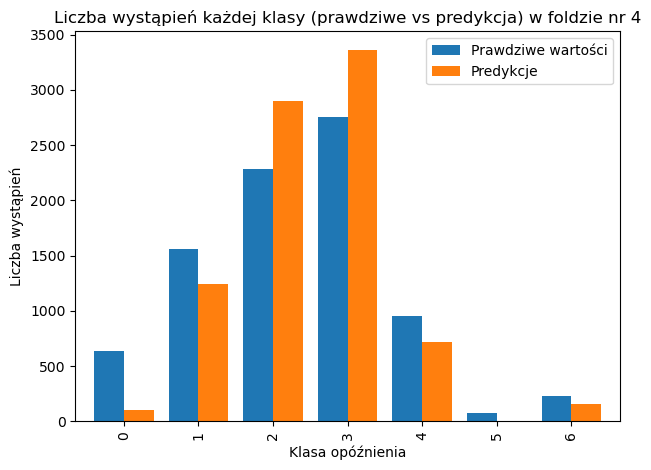

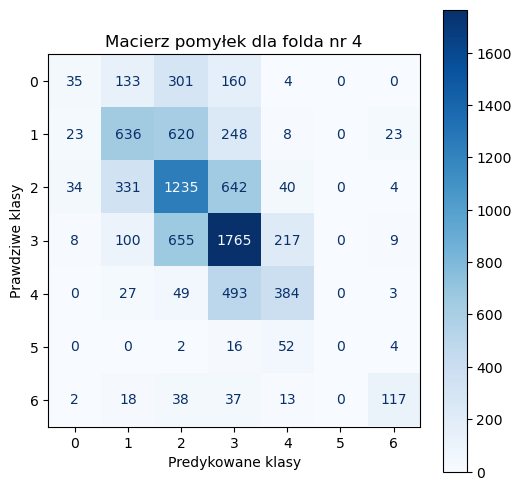

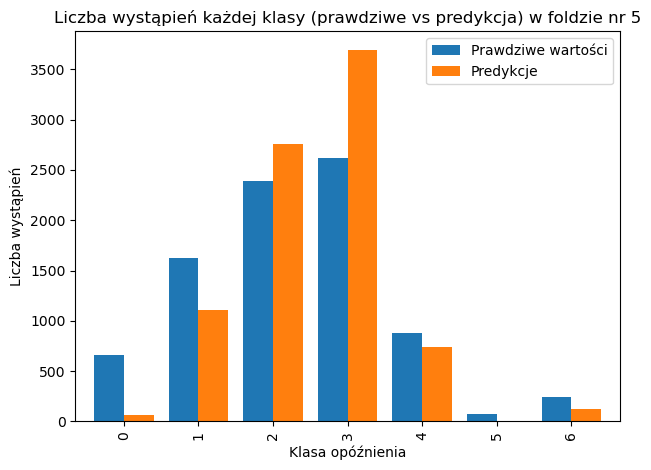

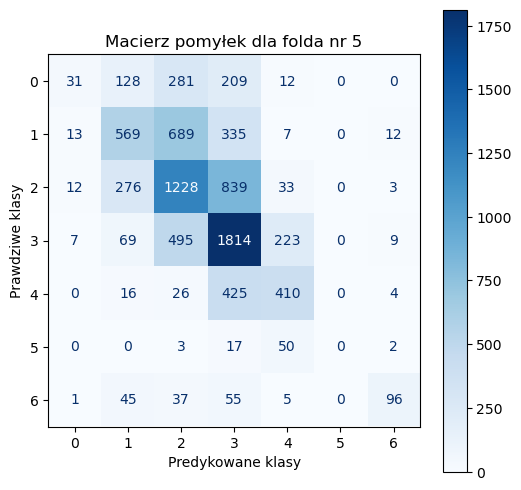

In [8]:

for i in range(5):
    predykcje=wyniki['fold_preds'][i]
    y_true_counts = predykcje['y_true'].value_counts().sort_index()
    y_pred_counts = predykcje['y_pred'].value_counts().sort_index()
    df_counts = pd.DataFrame({
    "Prawdziwe wartości": y_true_counts,
    "Predykcje": y_pred_counts
    }).fillna(0).astype(int)

    df_counts.plot(kind="bar", width=0.8)
    plt.xlabel("Klasa opóźnienia")
    plt.ylabel("Liczba wystąpień")
    plt.title(f"Liczba wystąpień każdej klasy (prawdziwe vs predykcja) w foldzie nr {i+1}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(predykcje['y_true'], predykcje['y_pred'])
    classes = sorted(predykcje['y_true'].unique())

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap='Blues')
    plt.title(f"Macierz pomyłek dla folda nr {i+1}")
    plt.xlabel("Predykowane klasy")
    plt.ylabel("Prawdziwe klasy")
    plt.show()

